### 1.1 Notebook Objectives

- Load the trained XGBoost model (`models/xgboost_pharma_demand.joblib`) and prepare the feature matrix.
- Compute SHAP values using `TreeExplainer` to evaluate feature contributions.
- Generate SHAP visualisations:
  - **Global visualisations:** *Summary Bar Plot* and *Beeswarm Plot* for overall model behavior.
  - **Local visualisation:** *Individual Breakdown Plot* for single-prediction explanations.
- Provide structured interpretations:
  - **General framework:** Role and methodology behind each SHAP plot.
  - **Project-specific findings:** Business-oriented insights applied to pharmaceutical demand forecasting.

### 1.2 Import Libraries & Configuration

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import shap

# Initialize JS visualization for SHAP interactive plots
shap.initjs()

# Define output directory for generated figures
output_dir = "../reports/figures"
os.makedirs(output_dir, exist_ok=True)
print("Libraries loaded and output directory ready.")

Libraries loaded and output directory ready.


## 2. Load Data & Model
### 2.1 Load Trained Model

In [2]:
import sys
from pathlib import Path

# Add root directory to path to import from src
sys.path.append(str(Path("../").resolve()))


from src.train import create_features

# 1. Load trained XGBoost model
model_path = "../models/xgboost_pharma_demand.joblib"
model = joblib.load(model_path)

# 2. Load raw dataset
data_path = "../data/pharmaceutical_demand_row.csv"
df_raw = pd.read_csv(data_path)

# Ensure date is parsed as datetime
df_raw["date"] = pd.to_datetime(df_raw["date"])

# 3. Apply feature engineering pipeline
df_features = create_features(df_raw)

# 4. Select exact feature set expected by XGBoost model
feature_cols = [
    "month",
    "dayofweek",
    "is_weekend",
    "stock_on_hand",
    "supplier_lead_time",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
]

X = df_features[feature_cols]

print(f"Model successfully loaded: {type(model)}")
print(f"Feature matrix shape: {X.shape}")
print("Features passed to SHAP:\n", X.columns.tolist())

2026-09-29 14:24:58,218 - INFO - Engineering dynamic features (calendar, lags, rolling statistics)...


Model successfully loaded: <class 'xgboost.sklearn.XGBRegressor'>
Feature matrix shape: (10650, 10)
Features passed to SHAP:
 ['month', 'dayofweek', 'is_weekend', 'stock_on_hand', 'supplier_lead_time', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_30']


### 2.2 Compute SHAP Values

In [3]:
# TreeExplainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

print("SHAP values computation completed successfully.")

SHAP values computation completed successfully.


## 3. SHAP Visualizations

### 3.1 Global Visualizations (Summary Bar & Beeswarm Plots)

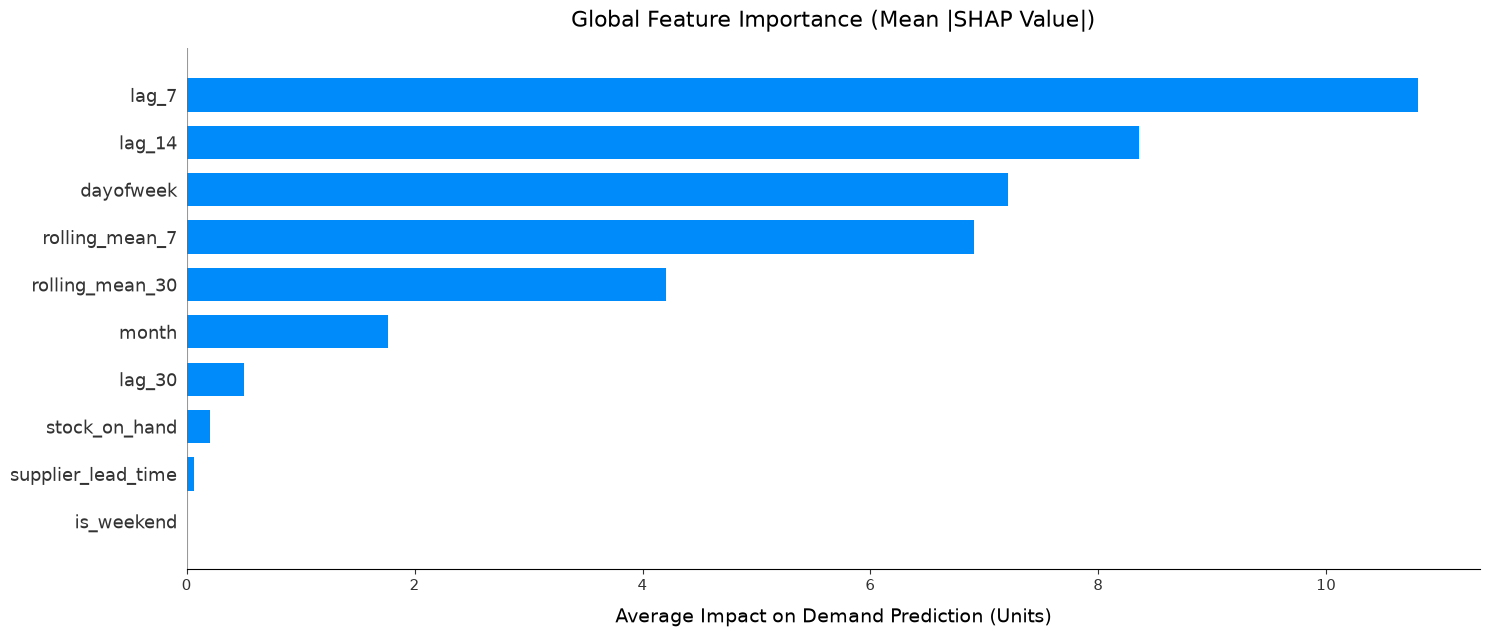

In [4]:
plt.close("all")

# Pass plot_size directly to SHAP so it leaves enough vertical space at the bottom
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    plot_size=(
        15,
        6,
    ),  # Height increased from 6 to 8 to avoid x-axis truncation
    show=False,
)

plt.title(
    "Global Feature Importance (Mean |SHAP Value|)",
    fontsize=16,
    pad=15,
)

plt.xlabel(
    "Average Impact on Demand Prediction (Units)",
    fontsize=14,
    labelpad=10,
)

# Save figure to file
plt.savefig(
    os.path.join(output_dir, "notebook", "shap_summary_bar.png"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

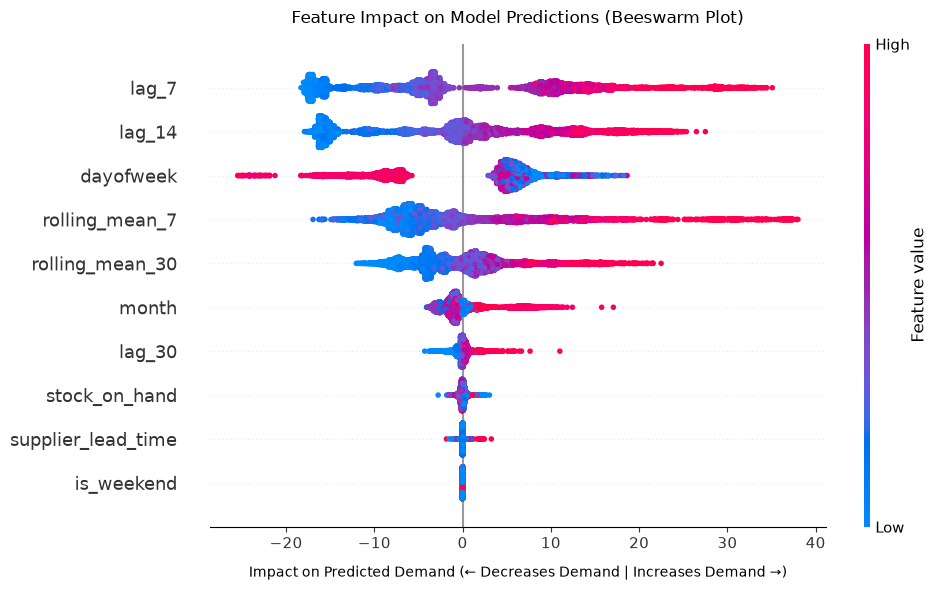

In [5]:
import matplotlib.pyplot as plt

plt.close("all")

# 1. Generate SHAP beeswarm plot
shap.summary_plot(shap_values, X, plot_size=(10, 6), show=False)

# 2. Custom title & business-oriented x-axis label
plt.title(
    "Feature Impact on Model Predictions (Beeswarm Plot)",
    fontsize=12,
    pad=15,
)
plt.xlabel(
    "Impact on Predicted Demand (← Decreases Demand | Increases Demand →)",
    fontsize=10,
    labelpad=10,
)

# 3. Adjust layout and export
plt.tight_layout()


plt.savefig(
    os.path.join(
        output_dir, "notebook", "shap_summary_beeswarm.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 3.2 Local Visualization (Individual Breakdown Plot)

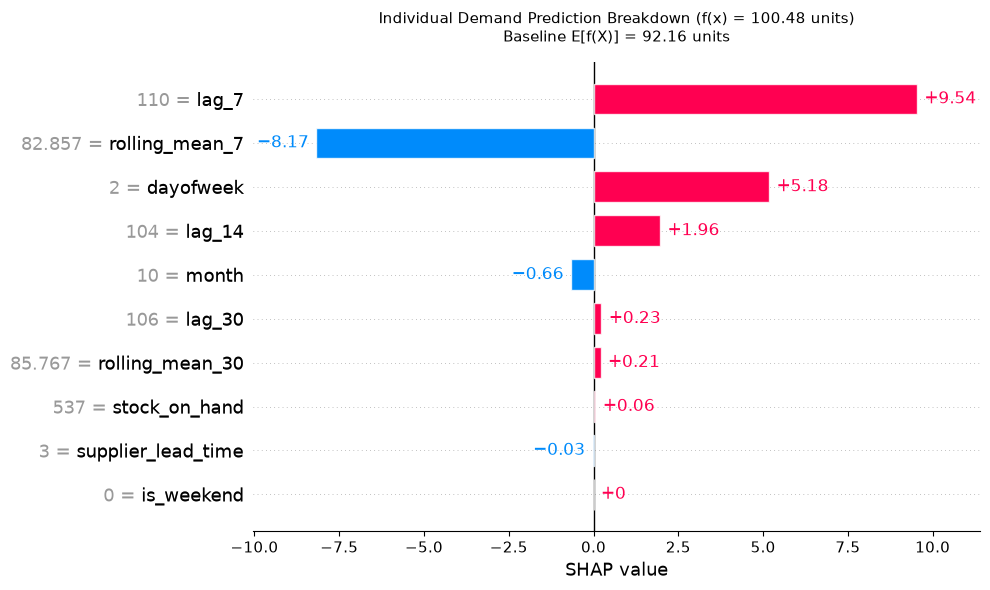

In [6]:
import matplotlib.pyplot as plt

plt.close("all")

# 1. Récupération dynamique de f(x) et de E[f(X)]
base_val = shap_values[0].base_values
fx_val = base_val + shap_values[0].values.sum()

# 2. Rendu bar plot
shap.plots.bar(shap_values[0], max_display=10, show=False)

# 3. Redimensionnement
fig = plt.gcf()
fig.set_size_inches(10, 6)

# 4. Titre et sous-titre dynamique intégrant la valeur de base E[f(X)]
plt.title(
    f"Individual Demand Prediction Breakdown (f(x) = {fx_val:.2f} units)\n"
    f"Baseline E[f(X)] = {base_val:.2f} units",
    fontsize=11,
    pad=15,
)

plt.tight_layout()

# 5. Sauvegarde et affichage
plt.savefig(
    os.path.join(output_dir, "notebook", "shap_waterfall_single.png"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

## 4. Global Interpretation

### 4.1 Features and Key Takeaways for Each Plot (General Framework)

* **Plot 1: SHAP Summary Bar Plot (Global Feature Importance)**
  * **Objective:** Quantify and rank the overall influence of each feature across the entire dataset.
  * **Key Takeaways:** Measures the average magnitude of impact ($|SHAP value|$) to quickly identify which variables drive model decisions the most.
  * **Practical Value:** Helps streamline the pipeline by filtering out low-impact features, optimizing performance, training speed, and memory usage.

* **Plot 2: SHAP Beeswarm Plot (Distribution and Direction of Impact)**
  * **Objective:** Visualize the distribution of impact and understand how variable values affect the target prediction.
  * **Key Takeaways:** Combines feature ranking with feature values (high vs. low) to reveal whether a variable increases or decreases the model output.
  * **Practical Value:** Validates model behavior against domain logic and helps detect anomalies, bias, or inconsistent feature relationships.

* **Plot 3: SHAP Waterfall Plot (Local Explainability of a Single Prediction)**
  * **Objective:** Explain a single prediction by detailing the exact contribution of each feature to the final result.
  * **Key Takeaways:** Shows the step-by-step transition from the baseline model expectation $E[f(X)]$ to the final predicted output $f(x)$ using positive (+) and negative (-) contributions.
  * **Practical Value:** Powers root-cause analysis, model auditing, and transparent user-facing dashboards or reporting tools.

### 4.2 Project-Specific Insights & Interpretation (Pharma Demand Case)

#### Recent Sales History is the Biggest Driver of Demand
* **Plot 1**: Sales recorded exactly 7 days ago (`lag_7`) and 14 days ago (`lag_14`) are the most important factors for predicting upcoming demand.
* **Plot 2**: High sales in the previous week (pink dots on the right) strongly drive the prediction upwards (up to +35 units), while low sales (blue dots on the left) lower the prediction by nearly 18 units.

#### The Day of the Week Plays a Decisive Role
* **Plots 1 & 2**: The day of the week (`dayofweek`) is the 3rd most influential factor. There is a clear separation: certain days of the week drop the predicted demand by up to 25 units, while others boost it.

#### Smoothed Trends (Rolling Means) Stabilize the Prediction
* **Plots 1 & 2**: The average sales over 7 days (`rolling_mean_7`) and 30 days (`rolling_mean_30`) provide a baseline adjustment. A high sales average over the last 7 days generally pushes the prediction upwards.

#### Stock and Supplier Lead Time Have a Negligible Impact on Sales
* **Plots 1 & 2**: Available stock levels (`stock_on_hand`) and supplier lead time (`supplier_lead_time`) are at the bottom of the ranking. Their points are concentrated around 0, meaning they barely change the demand forecast.

#### Concrete Application on a Specific Prediction Example
* **Plot 3**: For this specific day, the expected average demand value was **92.16 units**.
* **Plot 3**: The final prediction rose to **100.48 units** (+8.32 units):
  * **Positive Factors**: Strong sales 7 days ago (`lag_7 = 110`) added **+9.54 units**, and the day of the week (`dayofweek = 2`) added **+5.18 units**.
  * **Negative Factors**: The recent 7-day average (`rolling_mean_7 = 82.857`) dragged the prediction down by **-8.17 units**.